In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned data from Week 1
df = pd.read_csv("cleaned_single_family_sales.csv", low_memory=False)
print("Shape:", df.shape)

Shape: (320506, 83)


In [3]:
# Keep required columns
cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]
df = df[cols].copy()

In [4]:
# Rename for easier use
df.columns = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

In [5]:
# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [6]:
# Remove missing values
df = df.dropna()
print(df.describe())

         ClosePrice     LivingArea       Bedrooms      Bathrooms       LotSize
count  3.147860e+05  314786.000000  314786.000000  314786.000000  3.147860e+05
mean   1.298407e+06    2035.491081       3.481759       2.615142  2.568318e+05
std    5.833866e+06    1059.217429       0.961015       1.156809  1.410703e+07
min    0.000000e+00       0.000000       0.000000       0.000000  0.000000e+00
25%    6.200000e+05    1377.000000       3.000000       2.000000  5.663000e+03
50%    8.900000e+05    1805.000000       3.000000       2.000000  7.245000e+03
75%    1.435000e+06    2424.000000       4.000000       3.000000  1.035000e+04
max    9.895000e+08  123764.000000      45.000000     153.000000  2.087221e+09


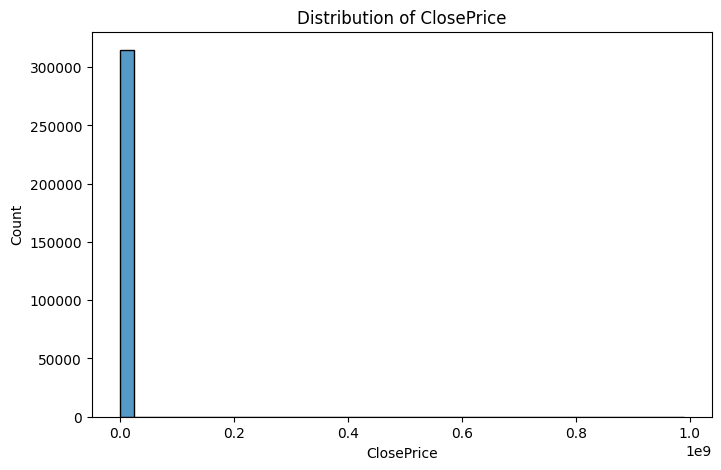

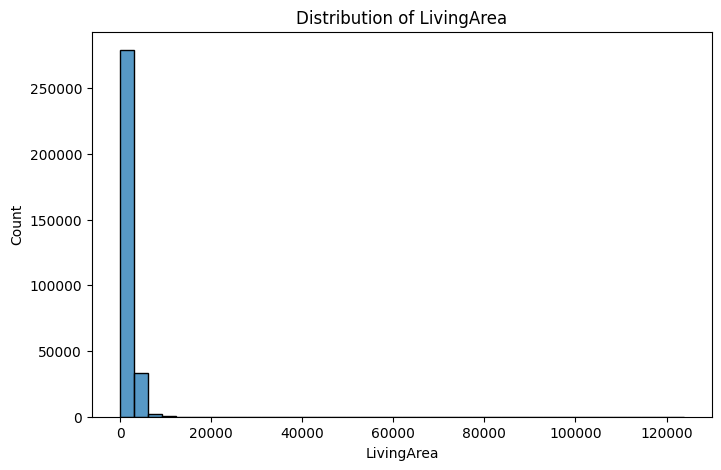

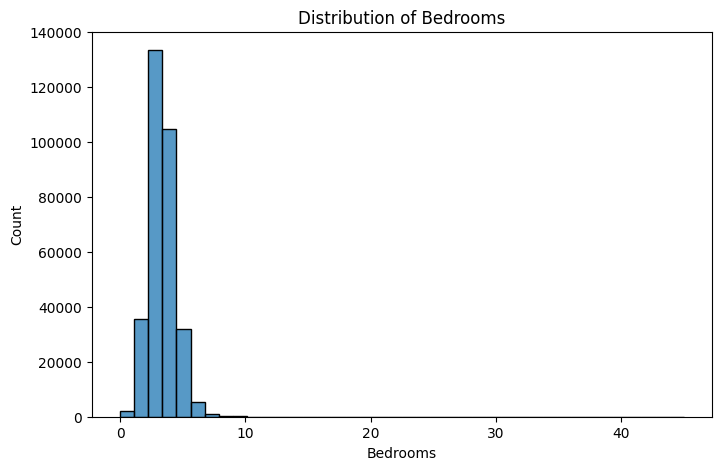

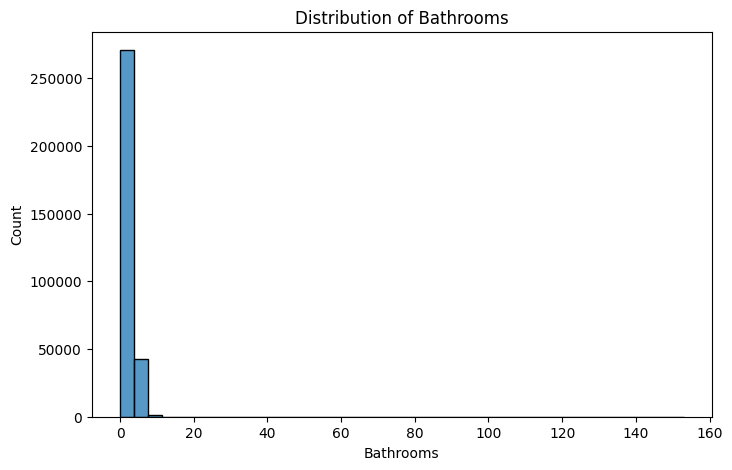

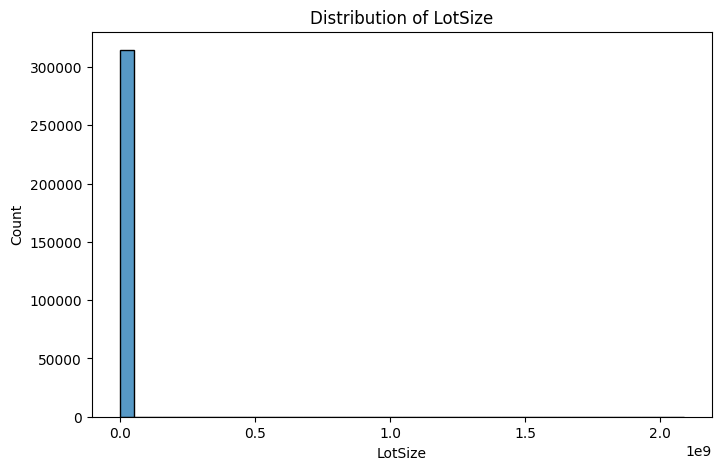

In [7]:
# Histograms
features = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]
for col in features:
    plt.figure(figsize=(8,5))
    sns.histplot(
        df[col],
        bins=40
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

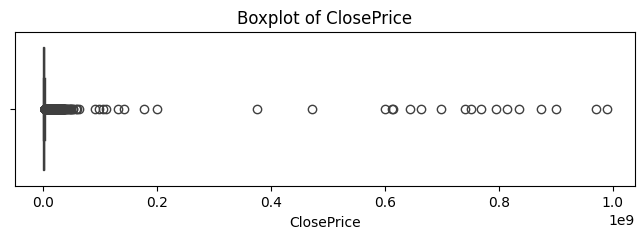

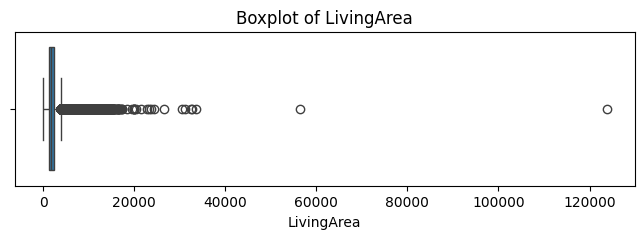

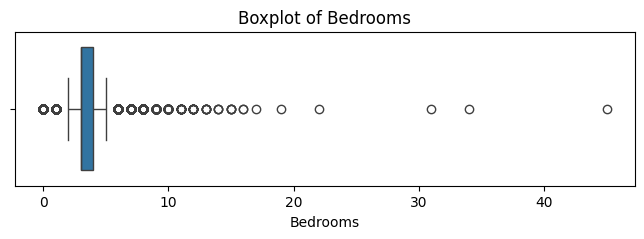

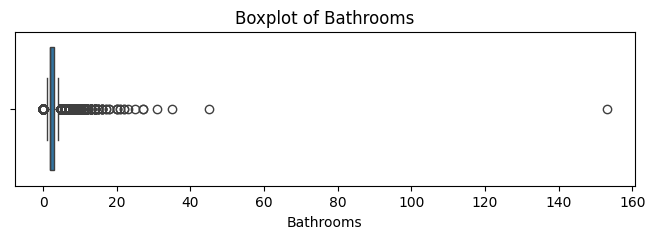

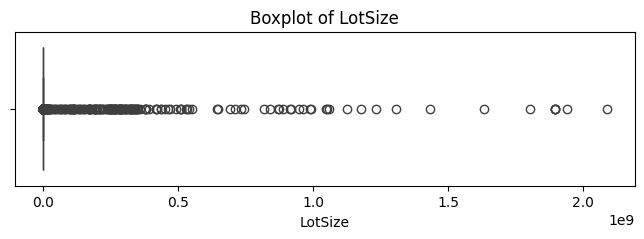

In [8]:
# Boxplots
for col in features:
    plt.figure(figsize=(8,2))
    sns.boxplot(
        x=df[col]
    )
    plt.title(f"Boxplot of {col}")
    plt.show()

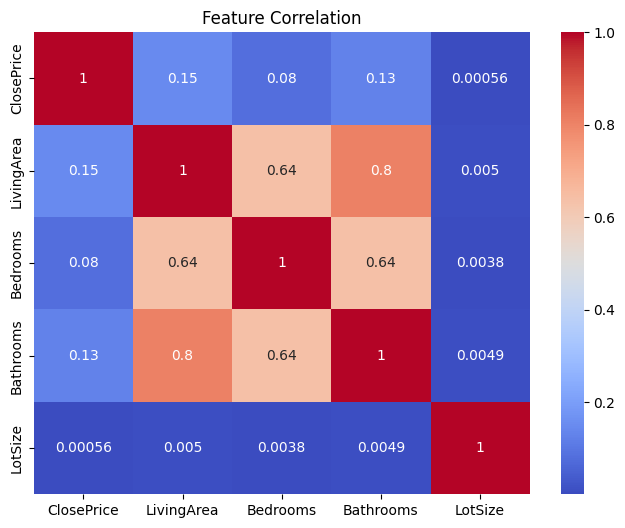

In [9]:
# Correlation
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation")
plt.show()